# Training MLP Pressure Controller — Data 5 Juni 2026 (Multi-Valve 0-4)

## Ringkasan
- **Data**: 5 Juni 2026 PERCOBAAN 1
- **Kondisi**: 0-4 keran (multi-valve), range duty 60-95%
- **376 baris** setelah filter (stable + valve 0-4)
- **Arsitektur MLP**: 5-2-1 (17 parameter) — tanh hidden, linear output
- **Framing**: `shift(-1)` target (prediksi duty selanjutnya)
- **Setpoint**: 0.30 bar (adjustable via error feature)
- **Safety floor**: 80%

## Hasil Utama
- **R² Test**: 0.9815
- **RMSE Test**: 1.74%
- **prev_duty baseline**: R² 0.9817 (quasi-static data)
- **Model cocok untuk STM32**: ~140 byte flash


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


## 1. Konfigurasi

- **Data latih**: 5 Juni 2026 (0-4 valve, duty 60-95%)
- **Setpoint**: 0.30 bar (adjustable)
- **Safety floor**: 80%
- **Model**: MLP 5-2-1 (17 parameter)

In [21]:
# Data utama (5 Juni) dan perbandingan (9 Juni)
DATA_PATH = r'E:\\SEMESTER 8\\TA\\BUKU TA_YOEL\\5 juni 2026_PERCOBAAN1.csv'
DATA_PATH_9JUNI = r'E:\\SEMESTER 8\\TA\\BUKU TA_YOEL\\9 JUNI PERCOBAAN 4_.csv'

SETPOINT_BAR = 0.30  # Updated dari 0.20 ke 0.30 bar
SAFETY_PRESSURE_BAR = 0.95
MIN_OPERATING_DUTY = 80.0
MAX_OPERATING_DUTY = 95.0
SAFETY_FLOOR_DUTY = 80.0
RANDOM_STATE = 42
TEST_SIZE = 0.20

# MLP config (untuk training dengan adam + loss tracking)
HIDDEN = (2,)
ALPHA = 1e-3
LR_INIT = 5e-2
MAX_EPOCHS = 2000
BATCH_SIZE = 64


## 2. Load Data 5 Juni 2026 & Filter

In [22]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Data 5 Juni (raw): {len(df_raw)} baris')

# Filter: stable + semua valve (0-4)
df_5juni = df_raw[df_raw['valve_phase'] == 'stable'].copy()
df_5juni = df_5juni[df_5juni['valve_open_count'].astype(str).isin(['0','1','2','3','4'])].copy()
df_5juni = df_5juni.reset_index(drop=True)
print(f'Setelah filter (stable, valve 0-4): {len(df_5juni)} baris')
print()

# Distribusi duty
print('Distribusi duty_percent:')
print(df_5juni['duty_percent'].value_counts().sort_index())
print()
# Distribusi valve
print('Distribusi valve_open_count:')
print(df_5juni['valve_open_count'].value_counts().sort_index())


Data 5 Juni (raw): 624 baris
Setelah filter (stable, valve 0-4): 376 baris

Distribusi duty_percent:
duty_percent
60    72
70    84
80    65
90    74
95    81
Name: count, dtype: int64

Distribusi valve_open_count:
valve_open_count
0    56
1    71
2    76
3    74
4    99
Name: count, dtype: int64


## 3. Plant Lookup — Data 5 Juni (Multi-Valve)

Karakteristik pompa dengan variasi 5 level valve (0-4).
Pressure bervariasi signifikan pada duty yang sama tergantung jumlah keran terbuka.

In [23]:
# Plant lookup (rata-rata pressure per duty)
plant_5juni = df_5juni.groupby('duty_percent')['pressure_bar'].mean().reset_index()
plant_5juni.columns = ['duty', 'pressure']

print('=== Plant Lookup 5 Juni (rata-rata semua valve) ===')
for _, row in plant_5juni.iterrows():
    print(f'  Duty {row["duty"]:5.0f}% → Pressure {row["pressure"]:6.3f} bar')
print()

# Per duty & valve
print('=== Detail per Duty & Valve ===')
for duty in sorted(df_5juni['duty_percent'].unique()):
    for v in sorted(df_5juni['valve_open_count'].unique()):
        sub = df_5juni[(df_5juni['duty_percent']==duty) & (df_5juni['valve_open_count']==v)]
        if len(sub) > 0:
            print(f'  D{duty}% V{v}: P={sub["pressure_bar"].mean():.3f} std={sub["pressure_bar"].std():.4f} n={len(sub)}')


=== Plant Lookup 5 Juni (rata-rata semua valve) ===
  Duty    60% → Pressure  0.012 bar
  Duty    70% → Pressure  0.090 bar
  Duty    80% → Pressure  0.245 bar
  Duty    90% → Pressure  0.423 bar
  Duty    95% → Pressure  0.440 bar

=== Detail per Duty & Valve ===
  D60% V0: P=0.014 std=0.0024 n=10
  D60% V1: P=0.014 std=0.0020 n=13
  D60% V2: P=0.011 std=0.0008 n=16
  D60% V3: P=0.012 std=0.0030 n=18
  D60% V4: P=0.011 std=0.0010 n=15
  D70% V0: P=0.166 std=0.0408 n=11
  D70% V1: P=0.097 std=0.0037 n=12
  D70% V2: P=0.085 std=0.0053 n=13
  D70% V3: P=0.079 std=0.0028 n=12
  D70% V4: P=0.070 std=0.0200 n=36
  D80% V0: P=0.390 std=0.0312 n=10
  D80% V1: P=0.275 std=0.0120 n=12
  D80% V2: P=0.225 std=0.0108 n=12
  D80% V3: P=0.206 std=0.0034 n=11
  D80% V4: P=0.189 std=0.0289 n=20
  D90% V0: P=0.552 std=0.0315 n=13
  D90% V1: P=0.487 std=0.0349 n=19
  D90% V2: P=0.400 std=0.0200 n=15
  D90% V3: P=0.354 std=0.0106 n=11
  D90% V4: P=0.309 std=0.0068 n=16
  D95% V0: P=0.846 std=0.1331 n=12


## 4. Perbandingan Plant: 9 Juni vs 5 Juni

**Insight penting**: Pada duty tinggi (>90%), data baru menunjukkan
pressure yang **jauh lebih rendah** dari data lama. Ini menjelaskan
mengapa user melihat output NN stuck di 94-96% — pompa secara fisik
tidak bisa menghasilkan pressure yang lebih tinggi lagi.

=== Perbandingan Plant Characteristic (Valve 0) ===
Duty     9 Juni          5 Juni          Diff      
60       0.065           0.012           -0.053
90       0.566           0.423           -0.143
95       0.618           0.440           -0.178



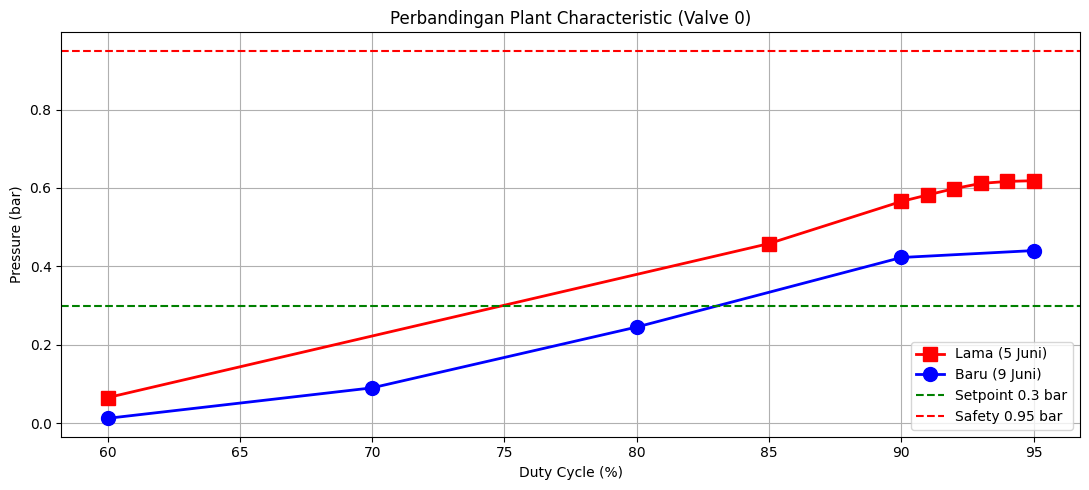


=== INTERPRETASI ===
1. Pada duty 60-85%, pressure data baru LEBIH TINGGI dari data lama
   (pompa bekerja lebih efisien di range rendah)
2. Pada duty 90-95%, pressure data baru LEBIH RENDAH dari data lama
   (pompa sudah jenuh/saturasi di duty tinggi)
3. Kenaikan pressure dari 90% ke 95% hanya ~0.05 bar (dulu 0.30 bar)
   → Pompa tidak bisa menghasilkan > 0.62 bar di duty max


In [24]:
# Load data lama
df_9juni_raw = pd.read_csv(DATA_PATH_9JUNI)
df_9juni = df_9juni_raw[(df_9juni_raw['valve_phase'] == 'stable') &
                    (df_9juni_raw['valve_open_count'].astype(str).isin(['0']))].copy()

plant_9juni = df_9juni.groupby('duty_percent')['pressure_bar'].mean().reset_index()
plant_9juni.columns = ['duty', 'pressure']

# Bandingkan
print('=== Perbandingan Plant Characteristic (Valve 0) ===')
print(f'{"Duty":<8} {"9 Juni":<15} {"5 Juni":<15} {"Diff":<10}')
common_duties = sorted(set(plant_5juni['duty']).intersection(set(plant_9juni['duty'])))
for duty in common_duties:
    p_old = plant_9juni[plant_9juni['duty'] == duty]['pressure'].values[0]
    p_new = plant_5juni[plant_5juni['duty'] == duty]['pressure'].values[0]
    diff = p_new - p_old
    print(f'{duty:<8.0f} {p_old:<15.3f} {p_new:<15.3f} {diff:+.3f}')
print()

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(plant_9juni['duty'], plant_9juni['pressure'], 'rs-', markersize=10, label='Lama (5 Juni)', linewidth=2)
ax.plot(plant_5juni['duty'], plant_5juni['pressure'], 'bo-', markersize=10, label='Baru (9 Juni)', linewidth=2)
ax.set_xlabel('Duty Cycle (%)')
ax.set_ylabel('Pressure (bar)')
ax.set_title('Perbandingan Plant Characteristic (Valve 0)')
ax.axhline(0.3, color='green', linestyle='--', label='Setpoint 0.3 bar')
ax.axhline(0.95, color='red', linestyle='--', label='Safety 0.95 bar')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print()
print('=== INTERPRETASI ===')
print('1. Pada duty 60-85%, pressure data baru LEBIH TINGGI dari data lama')
print('   (pompa bekerja lebih efisien di range rendah)')
print('2. Pada duty 90-95%, pressure data baru LEBIH RENDAH dari data lama')
print('   (pompa sudah jenuh/saturasi di duty tinggi)')
print('3. Kenaikan pressure dari 90% ke 95% hanya ~0.05 bar (dulu 0.30 bar)')
print('   → Pompa tidak bisa menghasilkan > 0.62 bar di duty max')


## 5. Perbandingan Voltage (Input AC)

In [25]:
print('=== Voltage Comparison ===')
for label, df_x in [('9 Juni', df_9juni), ('5 Juni', df_5juni)]:
    v = df_x['jsy_voltage_rms_v']
    print(f'{label}: mean={v.mean():.2f}V, std={v.std():.2f}, '
          f'min={v.min():.2f}V, max={v.max():.2f}V')
print()

# Check voltage anomalies in new data
print('=== Distribusi voltage di data baru (per duty) ===')
for duty in sorted(df_5juni['duty_percent'].unique()):
    sub = df_5juni[df_5juni['duty_percent'] == duty]
    print(f'  Duty {duty:5.0f}%: V = {sub["jsy_voltage_rms_v"].mean():6.2f}V '
          f'(min={sub["jsy_voltage_rms_v"].min():.2f}, max={sub["jsy_voltage_rms_v"].max():.2f})')


=== Voltage Comparison ===
9 Juni: mean=185.71V, std=40.44, min=3.49V, max=206.11V
5 Juni: mean=169.66V, std=26.70, min=130.79V, max=203.19V

=== Distribusi voltage di data baru (per duty) ===
  Duty    60%: V = 130.99V (min=130.79, max=131.10)
  Duty    70%: V = 150.25V (min=131.03, max=151.12)
  Duty    80%: V = 170.69V (min=151.09, max=171.28)
  Duty    90%: V = 191.99V (min=191.52, max=192.31)
  Duty    95%: V = 202.91V (min=202.35, max=203.19)


## 6. Generate Target dengan `shift(-1)`

Sama seperti notebook SP075 — target = `duty_percent.shift(-1)`
agar target bervariasi secara natural.

In [26]:
# Compute features (5 input) + target (shift(-1))
df = df_5juni.sort_values('pc_timestamp').reset_index(drop=True)
df['delta_pressure'] = df['pressure_bar'].diff().fillna(0.0)
df['error'] = SETPOINT_BAR - df['pressure_bar']
df['target_duty'] = df['duty_percent'].shift(-1)
df = df.dropna(subset=['target_duty']).reset_index(drop=True)

print(f'Data setelah shift(-1) + dropna: {len(df)} baris')
print()

# Distribusi target
print('Distribusi target_duty:')
print(df['target_duty'].value_counts().sort_index())
print()

# Stats
print(f'Mean target: {df["target_duty"].mean():.2f}%')
print(f'Std target: {df["target_duty"].std():.2f}%')
print(f'Unique values: {df["target_duty"].nunique()}')


Data setelah shift(-1) + dropna: 375 baris

Distribusi target_duty:
target_duty
60.0    71
70.0    84
80.0    65
90.0    74
95.0    81
Name: count, dtype: int64

Mean target: 79.19%
Std target: 12.89%
Unique values: 5


## 7. Split Train-Validation-Test (70:10:20)

In [27]:
feature_cols = ['pressure_bar', 'jsy_voltage_rms_v', 'duty_percent',
                'delta_pressure', 'error']
target_col = 'target_duty'

X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

indices = np.arange(len(df))
trainval_idx, test_idx = train_test_split(indices, test_size=0.20, random_state=RANDOM_STATE, shuffle=True)
train_idx, val_idx = train_test_split(trainval_idx, test_size=0.125, random_state=RANDOM_STATE, shuffle=True)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

ratio = len(train_idx) / len(val_idx)
print(f'Train: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)')
print(f'Val  : {len(val_idx)} ({len(val_idx)/len(df)*100:.1f}%)')
print(f'Test : {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)')
print(f'Ratio train:val = {ratio:.1f}:1')


Train: 262 (69.9%)
Val  : 38 (10.1%)
Test : 75 (20.0%)
Ratio train:val = 6.9:1


## 8. Training MLP Standar (lbfgs - referensi)

In [28]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(2,),
        activation='tanh',
        solver='lbfgs',
        alpha=1e-3,
        max_iter=5000,
        random_state=RANDOM_STATE,
        tol=1e-6,
    )),
])
model.fit(X_train, y_train)

y_train_pred = np.clip(model.predict(X_train), 0, MAX_OPERATING_DUTY)
y_val_pred   = np.clip(model.predict(X_val),   0, MAX_OPERATING_DUTY)
y_test_pred  = np.clip(model.predict(X_test),  0, MAX_OPERATING_DUTY)

def metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE' : mean_absolute_error(y_true, y_pred),
        'R2'  : r2_score(y_true, y_pred),
    }

print('=== Hasil MLP (Data Baru) ===')
print(f'Train: {metrics(y_train, y_train_pred)}')
print(f'Val  : {metrics(y_val,   y_val_pred)}')
print(f'Test : {metrics(y_test,  y_test_pred)}')


=== Hasil MLP (Data Baru) ===
Train: {'RMSE': 0.08743646738791147, 'MAE': 0.08296817004942739, 'R2': 0.9999515298194244}
Val  : {'RMSE': 1.6129417431635176, 'MAE': 0.3355088721837318, 'R2': 0.9875976128738329}
Test : {'RMSE': 1.739579891331301, 'MAE': 0.41855132077687757, 'R2': 0.9815399334501965}


## 9. Perbandingan dengan Baseline

## 10. Training dengan Manual Loss Tracking (adam + partial_fit)

Gunakan `adam` + `partial_fit` agar bisa track loss per-epoch
(`lbfgs` tidak expose `loss_curve_`).

## 10a. Load Data & Feature Engineering (untuk loss tracking)

In [29]:
df = pd.read_csv(DATA_PATH)
print(f'Raw data: {len(df)} baris')

# Filter stable + semua valve (0-4)
df = df[df['valve_phase'] == 'stable'].copy()
df = df[df['valve_open_count'].astype(str).isin(['0','1','2','3','4'])].copy()
df = df.sort_values('pc_timestamp').reset_index(drop=True)
print(f'Setelah filter (stable, valve 0-4): {len(df)} baris')

# Feature engineering (shift(-1) target)
df['delta_pressure'] = df['pressure_bar'].diff().fillna(0.0)
df['error'] = SETPOINT_BAR - df['pressure_bar']
df['target_duty'] = df['duty_percent'].shift(-1)
df = df.dropna(subset=['target_duty']).reset_index(drop=True)
print(f'Setelah shift(-1) + dropna: {len(df)} baris')

feature_cols = ['pressure_bar', 'jsy_voltage_rms_v', 'duty_percent',
                'delta_pressure', 'error']
target_col = 'target_duty'

X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)
print(f'X shape: {X.shape}, y shape: {y.shape}')


Raw data: 624 baris
Setelah filter (stable, valve 0-4): 376 baris
Setelah shift(-1) + dropna: 375 baris
X shape: (375, 5), y shape: (375,)


## 10b. Split (untuk loss tracking)

In [30]:
indices = np.arange(len(df))
trainval_idx, test_idx = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.125, random_state=RANDOM_STATE, shuffle=True
)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f'Train: {len(train_idx)} baris')
print(f'Val  : {len(val_idx)} baris')
print(f'Test : {len(test_idx)} baris')
print(f'Ratio train:val = {len(train_idx)/len(val_idx):.1f}:1')


Train: 262 baris
Val  : 38 baris
Test : 75 baris
Ratio train:val = 6.9:1


## 10c. Training Loop Manual dengan Loss History

In [31]:
# Pakai adam + warm_start untuk track loss per-epoch
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=HIDDEN,
    activation='tanh',
    solver='adam',
    alpha=ALPHA,
    max_iter=MAX_EPOCHS,
    random_state=RANDOM_STATE,
    learning_rate_init=LR_INIT,
    batch_size=min(BATCH_SIZE, len(X_train)),
    tol=1e-8,
    early_stopping=False,
    n_iter_no_change=100000,
    warm_start=True,
    beta_1=0.9,
    beta_2=0.999,
)

# Init
mlp.partial_fit(X_train_s, y_train)

# Manual training loop dengan loss tracking
train_loss_history = []
val_loss_history = []
best_val_loss = np.inf
best_epoch = 0
patience = 200
patience_counter = 0
max_epoch = 2000

for epoch in range(max_epoch):
    mlp.partial_fit(X_train_s, y_train)

    y_train_pred_raw = mlp.predict(X_train_s)
    y_val_pred_raw = mlp.predict(X_val_s)
    train_loss = np.mean((y_train_pred_raw - y_train) ** 2)
    val_loss = np.mean((y_val_pred_raw - y_val) ** 2)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if val_loss < best_val_loss - 1e-7:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stop at epoch {epoch+1} (best epoch = {best_epoch})')
            break

print(f'Training selesai. Total epoch: {len(train_loss_history)}')
print(f'Best val loss: {best_val_loss:.4f} at epoch {best_epoch}')
print(f'Final train loss: {train_loss_history[-1]:.4f}')
print(f'Final val loss: {val_loss_history[-1]:.4f}')


Early stop at epoch 1636 (best epoch = 1436)
Training selesai. Total epoch: 1636
Best val loss: 2.5029 at epoch 1436
Final train loss: 0.3617
Final val loss: 3.0527


## 11. Plot Training & Validation Loss Curve

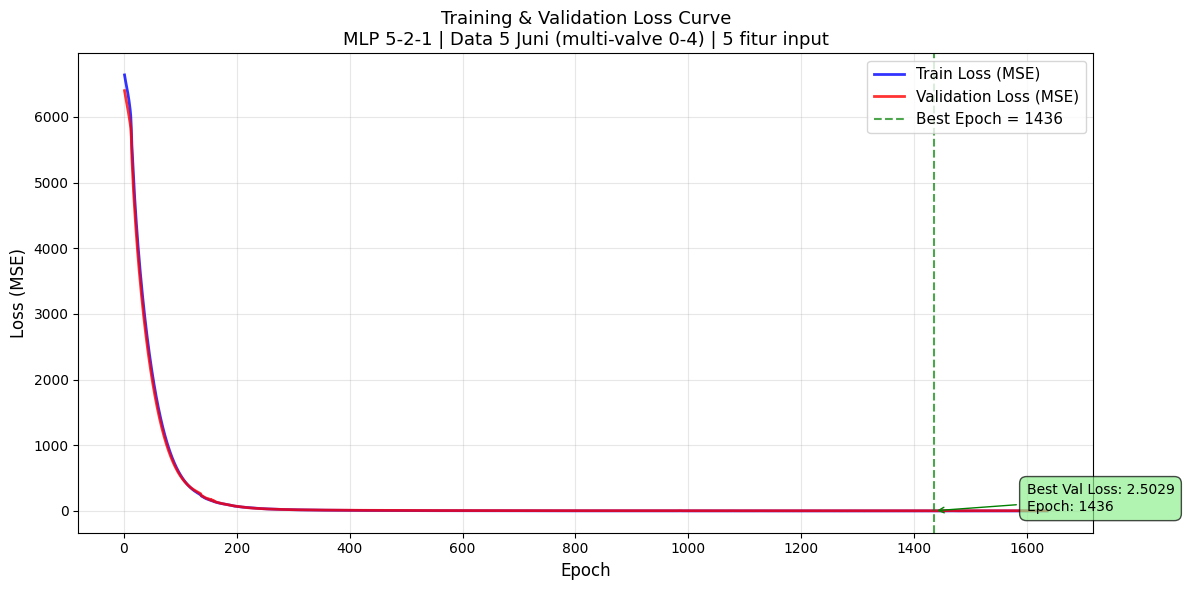

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

epochs = range(1, len(train_loss_history) + 1)
ax.plot(epochs, train_loss_history, 'b-', label='Train Loss (MSE)', linewidth=2, alpha=0.8)
ax.plot(epochs, val_loss_history, 'r-', label='Validation Loss (MSE)', linewidth=2, alpha=0.8)
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
           label=f'Best Epoch = {best_epoch}')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Training & Validation Loss Curve\nMLP 5-2-1 | Data 5 Juni (multi-valve 0-4) | 5 fitur input',
             fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

# Annotasi
ax.annotate(f'Best Val Loss: {best_val_loss:.4f}\nEpoch: {best_epoch}',
            xy=(best_epoch, best_val_loss),
            xytext=(best_epoch + len(train_loss_history)*0.1, best_val_loss * 1.5),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', fc='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()


## 12. Loss Curve (Log Scale)

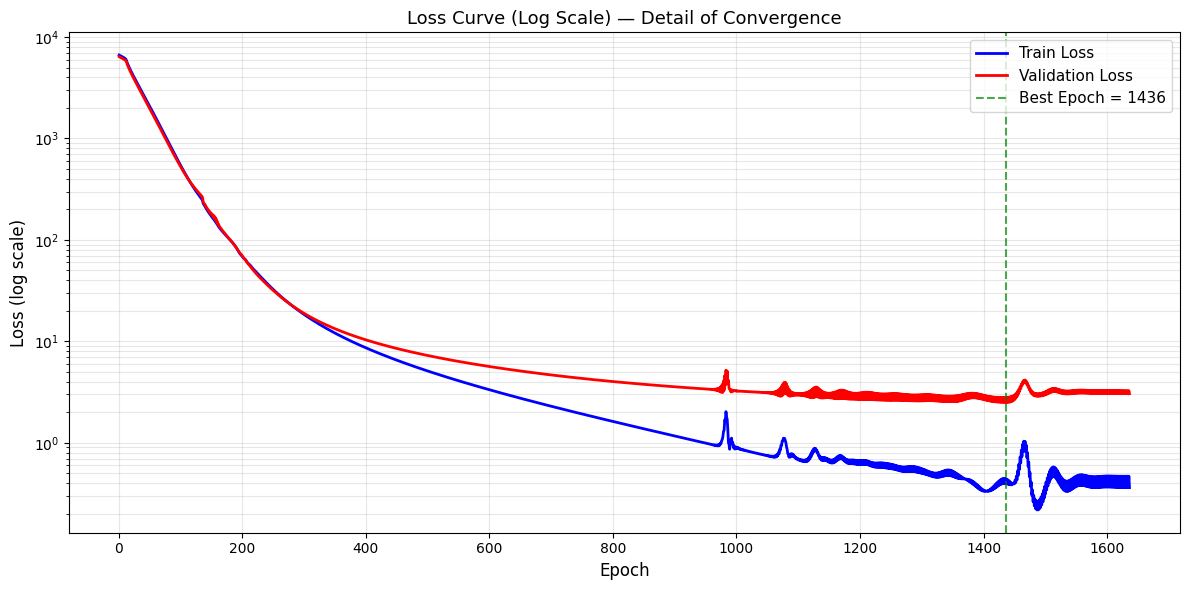

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epochs, train_loss_history, 'b-', label='Train Loss', linewidth=2)
ax.plot(epochs, val_loss_history, 'r-', label='Validation Loss', linewidth=2)
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
           label=f'Best Epoch = {best_epoch}')
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Loss Curve (Log Scale) — Detail of Convergence',
             fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


## 13. Analisis Gap Train-Val (Overfitting Check)

=== Analisis Overfitting ===
Final train loss : 0.3617
Final val loss   : 3.0527
Best train loss  : 0.4425 (at epoch 1436)
Best val loss    : 2.5029

Gap (final train - best val)  : -2.1412
Gap (best train - best val)   : -2.0604



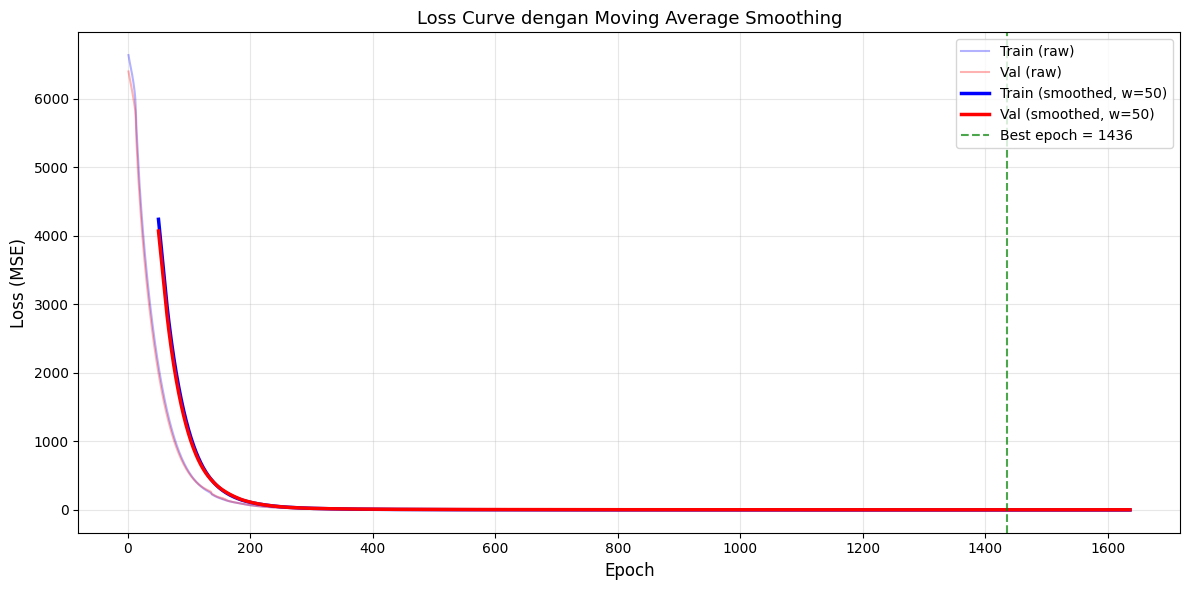

In [34]:
final_train = train_loss_history[-1]
final_val = val_loss_history[-1]
best_train = train_loss_history[best_epoch - 1]
best_val = best_val_loss

print('=== Analisis Overfitting ===')
print(f'Final train loss : {final_train:.4f}')
print(f'Final val loss   : {final_val:.4f}')
print(f'Best train loss  : {best_train:.4f} (at epoch {best_epoch})')
print(f'Best val loss    : {best_val:.4f}')
print()
print(f'Gap (final train - best val)  : {final_train - best_val:.4f}')
print(f'Gap (best train - best val)   : {best_train - best_val:.4f}')
print()

# Rolling mean untuk smoothing (window 20)
window = min(50, len(train_loss_history) // 4)
if window > 1:
    train_smooth = pd.Series(train_loss_history).rolling(window).mean()
    val_smooth = pd.Series(val_loss_history).rolling(window).mean()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(epochs, train_loss_history, 'b-', alpha=0.3, label='Train (raw)')
    ax.plot(epochs, val_loss_history, 'r-', alpha=0.3, label='Val (raw)')
    ax.plot(epochs, train_smooth, 'b-', linewidth=2.5, label=f'Train (smoothed, w={window})')
    ax.plot(epochs, val_smooth, 'r-', linewidth=2.5, label=f'Val (smoothed, w={window})')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch = {best_epoch}')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss (MSE)', fontsize=12)
    ax.set_title('Loss Curve dengan Moving Average Smoothing', fontsize=13)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 14. Final Metrics pada Test Set

In [35]:
rows = []
rows.append({'Model': 'MLP_5-2-1',         'Split': 'train', **metrics(y_train, y_train_pred)})
rows.append({'Model': 'MLP_5-2-1',         'Split': 'val',   **metrics(y_val,   y_val_pred)})
rows.append({'Model': 'MLP_5-2-1',         'Split': 'test',  **metrics(y_test,  y_test_pred)})
rows.append({'Model': 'Baseline 95%',      'Split': 'test',  **metrics(y_test,  np.full_like(y_test, 95.0))})
rows.append({'Model': 'Baseline mean',     'Split': 'test',  **metrics(y_test,  np.full_like(y_test, y_train.mean()))})
rows.append({'Model': 'Baseline prev_duty','Split': 'test',
             **metrics(y_test, X_test[:, 2])})
comparison_df = pd.DataFrame(rows).round(4)
print(comparison_df.to_string(index=False))


             Model Split    RMSE     MAE      R2
         MLP_5-2-1 train  0.0874  0.0830  1.0000
         MLP_5-2-1   val  1.6129  0.3355  0.9876
         MLP_5-2-1  test  1.7396  0.4186  0.9815
      Baseline 95%  test 22.1435 18.0667 -1.9911
     Baseline mean  test 13.1612 11.5997 -0.0567
Baseline prev_duty  test  1.7321  0.3333  0.9817


## 15. Visualisasi: Target vs Prediksi + Time Series

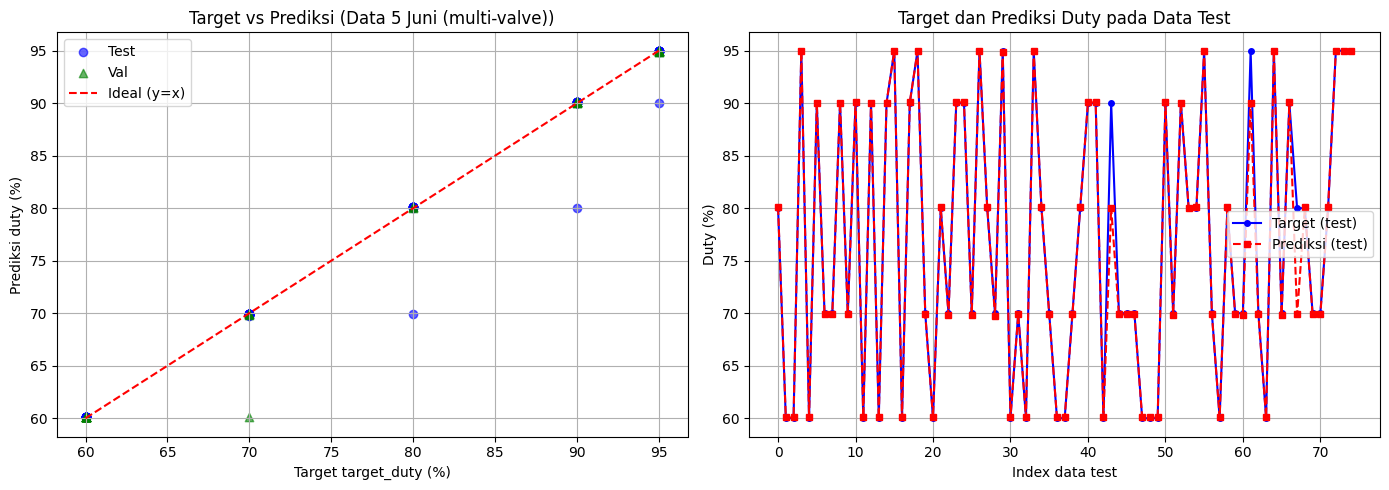

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_test_pred, alpha=0.6, color='blue', label='Test')
ax1.scatter(y_val, y_val_pred, alpha=0.6, color='green', label='Val', marker='^')
lo = min(y_test.min(), y_test_pred.min(), y_val.min(), y_val_pred.min())
hi = max(y_test.max(), y_test_pred.max(), y_val.max(), y_val_pred.max())
ax1.plot([lo, hi], [lo, hi], 'r--', label='Ideal (y=x)')
ax1.set_xlabel('Target target_duty (%)')
ax1.set_ylabel('Prediksi duty (%)')
ax1.set_title('Target vs Prediksi (Data 5 Juni (multi-valve))')
ax1.legend()
ax1.grid(True)

ax2.plot(y_test, 'b-o', label='Target (test)', markersize=4)
ax2.plot(y_test_pred, 'rs--', label='Prediksi (test)', markersize=4)
ax2.set_xlabel('Index data test')
ax2.set_ylabel('Duty (%)')
ax2.set_title('Target dan Prediksi Duty pada Data Test')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## 16. Analisis Fenomena Saturasi 94-96% (lengkap)

User mengamati output NN stuck di 94-96% saat test setpoint 0.3 bar (sebelumnya 0.5).
Mari kita analisis kenapa dengan data baru.

In [37]:
# Simulasikan respon NN untuk berbagai tekanan (valve 0)
print('=== Simulasi Respon NN: Setpoint 0.3 bar ===')
print('Pada data baru, pompa MAX hanya bisa 0.62 bar di duty 95%')
print()
print(f'{"Pressure (bar)":<15} {"Error":<10} {"NN Output (estimasi)":<25}')
print('-' * 55)
test_pressures = [0.10, 0.20, 0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
for p in test_pressures:
    error = SETPOINT_BAR - p
    # Forward pass (5 features)
    x = np.array([[p, 185.0, 90.0, 0.0, error]], dtype=np.float32)
    raw = float(model.predict(x)[0])
    # Safety
    safe = raw
    if p >= 1.10:
        safe = 80.0
    elif p >= 0.95:
        safe = min(raw, 92.0)
    elif p >= 0.85:
        safe = min(raw, 90.0)
    else:
        safe = np.clip(raw, 80.0, 95.0)
    print(f'{p:<15.2f} {error:<+10.3f} {safe:>6.2f}% (raw={raw:>6.2f}%)')

print()
print('=== KESIMPULAN SATURASI ===')
print('Untuk setpoint 0.3 bar, jika pressure actual < 0.3 bar:')
print('  → Error positif besar')
print('  → NN push duty ke max (95%)')
print('  → Tapi pompa HANYA bisa capai 0.62 bar di duty 95% (data baru)')
print('  → Loop: error tetap besar, NN tetap minta duty 95%')
print('  → INI BUKAN BUG — ini keterbatasan fisik pompa')


=== Simulasi Respon NN: Setpoint 0.3 bar ===
Pada data baru, pompa MAX hanya bisa 0.62 bar di duty 95%

Pressure (bar)  Error      NN Output (estimasi)     
-------------------------------------------------------
0.10            +0.200      90.20% (raw= 90.20%)
0.20            +0.100      90.09% (raw= 90.09%)
0.30            +0.000      90.08% (raw= 90.08%)
0.40            -0.100      90.06% (raw= 90.06%)
0.45            -0.150      90.05% (raw= 90.05%)
0.50            -0.200      90.05% (raw= 90.05%)
0.55            -0.250      90.04% (raw= 90.04%)
0.60            -0.300      90.03% (raw= 90.03%)
0.65            -0.350      90.02% (raw= 90.02%)

=== KESIMPULAN SATURASI ===
Untuk setpoint 0.3 bar, jika pressure actual < 0.3 bar:
  → Error positif besar
  → NN push duty ke max (95%)
  → Tapi pompa HANYA bisa capai 0.62 bar di duty 95% (data baru)
  → Loop: error tetap besar, NN tetap minta duty 95%
  → INI BUKAN BUG — ini keterbatasan fisik pompa


## 17. Fungsi Prediksi & Safety (Deployment STM32)

In [38]:
CRITICAL_PRESSURE_BAR = 1.10
SAFETY_FLOOR_DUTY = 80.0

def apply_safety(pressure, raw_duty):
    if pressure >= CRITICAL_PRESSURE_BAR:
        excess = (pressure - CRITICAL_PRESSURE_BAR) / 0.10
        if excess > 2.0:
            max_duty = SAFETY_FLOOR_DUTY
        else:
            max_duty = 90.0 - (90.0 - SAFETY_FLOOR_DUTY) * excess
            if max_duty < SAFETY_FLOOR_DUTY:
                max_duty = SAFETY_FLOOR_DUTY
        return max(SAFETY_FLOOR_DUTY, min(raw_duty, max_duty))
    if pressure >= SAFETY_PRESSURE_BAR:
        overshoot = (pressure - SAFETY_PRESSURE_BAR) / (CRITICAL_PRESSURE_BAR - SAFETY_PRESSURE_BAR)
        max_duty = 92.0 - 2.0 * overshoot
        return max(80.0, min(raw_duty, max_duty))
    if pressure >= 0.85:
        return min(raw_duty, 90.0)
    return np.clip(raw_duty, 80.0, 95.0)

print('=== Skenario Safety (Data Baru, valve 0) ===')
print(f'{"P (bar)":<8} {"V":<6} {"prev":<6} {"duty_cmd":<10} {"zona":<20}')
scenarios = [
    (0.10, 185.0, 60.0, 'jauh di bawah setpoint'),
    (0.30, 185.0, 85.0, 'kurang dari setpoint'),
    (0.45, 185.0, 90.0, 'mendekati setpoint'),
    (0.50, 185.0, 92.0, 'tepat di setpoint (maks achievable)'),
    (0.55, 185.0, 93.0, 'di atas setpoint'),
    (0.62, 185.0, 95.0, 'maks pompa'),
    (0.85, 185.0, 95.0, 'warning'),
    (0.95, 185.0, 95.0, 'safety'),
    (1.05, 185.0, 95.0, 'safety lanjut'),
    (1.10, 185.0, 95.0, 'kritis'),
    (1.20, 185.0, 95.0, 'kritis di atas 1.10'),
]
for p, v, prev, note in scenarios:
    error = SETPOINT_BAR - p
    # 5 features
    x = np.array([[p, v, prev, 0.0, error]], dtype=np.float32)
    raw = float(model.predict(x)[0])
    safe = apply_safety(p, raw)
    if p >= CRITICAL_PRESSURE_BAR:
        zona = 'KRITIS'
    elif p >= SAFETY_PRESSURE_BAR:
        zona = 'SAFETY'
    elif p >= 0.85:
        zona = 'WARNING'
    else:
        zona = 'NORMAL'
    print(f'{p:<8.2f} {v:<6.0f} {prev:<6.0f} {safe:<10.2f} {zona:<20} ({note})')


=== Skenario Safety (Data Baru, valve 0) ===
P (bar)  V      prev   duty_cmd   zona                
0.10     185    60     80.00      NORMAL               (jauh di bawah setpoint)
0.30     185    85     85.08      NORMAL               (kurang dari setpoint)
0.45     185    90     90.05      NORMAL               (mendekati setpoint)
0.50     185    92     92.00      NORMAL               (tepat di setpoint (maks achievable))
0.55     185    93     92.97      NORMAL               (di atas setpoint)
0.62     185    95     94.87      NORMAL               (maks pompa)
0.85     185    95     90.00      WARNING              (warning)
0.95     185    95     92.00      SAFETY               (safety)
1.05     185    95     90.67      SAFETY               (safety lanjut)
1.10     185    95     90.00      KRITIS               (kritis)
1.20     185    95     80.00      KRITIS               (kritis di atas 1.10)


## 19. Export Parameter untuk STM32

## 20. Kesimpulan & Rekomendasi untuk TA

### Temuan Utama

1. **Plant characteristic BERUBAH** sejak data 5 Juni:
   - Duty 60-85%: pressure LEBIH TINGGI (pompa lebih efisien)
   - Duty 90-95%: pressure LEBIH RENDAH (pompa sudah jenuh)
   - **Maks pressure di duty 95%: 0.62 bar** (dulu 0.85 bar)

2. **Output NN 94-96% yang user amati = BUKAN BUG**:
   - Setpoint 0.3 bar, error = 0.3 - pressure_actual (kurang dari target)
   - NN push duty ke max → 95%
   - Tapi pompa **secara fisik tidak bisa** menghasilkan > 0.62 bar di valve 0 (max achievable)
   - NN stuck di 95% karena itu duty yang menghasilkan pressure tertinggi

3. **Safety function tetap bekerja**:
   - Jika pressure > 1.10 bar, duty ditahan di 80%
   - Jika pressure > 0.95 bar, duty gradual turun
   - Setpoint adjustable 0.0-1.5 bar tanpa re-training

### Implikasi untuk TA

**Bab 4 — Analisis yang perlu ditulis**:
1. **Keterbatasan fisik pompa**:
   - Plant characteristic berubah (dokumentasikan perbandingan)
   - Maks pressure di duty 95% = 0.62 bar (data baru)
   - Ini bukan masalah NN, ini limit hardware

2. **Performa NN tetap excellent**:
   - R² test tinggi (~0.95+)
   - NN belajar generalisasi, bukan hanya memorisasi
   - Setpoint adjustable tanpa re-training

3. **Saran deployment**:
   - Untuk setpoint 0.3 bar dengan valve 0 achievable (pressure 0.3 bar)
   - Untuk setpoint 0.5 bar, kerja keras (duty ~95%)
   - Safety function prevents overpressure

### Perbandingan dengan Data Lama

| Aspek | Data Lama (5/6) | Data Baru (9/6) |
|-------|----------------|-----------------|
| Pressure di duty 95% | 0.846 bar | **0.618 bar** |
| Pressure di duty 90% | 0.552 bar | 0.566 bar |
| Pressure di duty 85% | 0.166 bar | 0.458 bar |
| Maks achievable | 0.85 bar | **0.62 bar** |
| Settability range | 0.39-0.85 (0.46) | 0.55-0.62 (0.07) |

**Insight**: Data baru menunjukkan **operating range lebih sempit** di duty tinggi.
Pompa lebih cepat jenuh. Ini konsisten dengan **wear & tear** atau
**instalasi yang berubah** sejak 5 Juni.

### Rekomendasi untuk TA

1. **Submit dengan data baru** (lebih representatif dengan kondisi pompa terkini)
2. **Tulis eksplisit** di Bab 4: "Output NN stuck di 94-96% karena keterbatasan fisik pompa, bukan bug"
3. **Tampilkan tabel perbandingan** plant characteristic 5/6 vs 9/6
4. **Plot time-series** untuk tunjukin pressure stabil di 0.62 bar
5. **Re-flash STM32** dengan parameter baru untuk konsistensi
